# Infos.json

In [41]:
import json
from PIL import Image
import numpy as np 

In [ ]:
p = "/home/zchen/Code/NeUF_new/data/simu_56/us/us0.jpg"
# p = "/home/zchen/Code/NeUF_new/data/bluephantom/sync/export/us/us0.jpg"
im = Image.open(p).convert('L')
# resize so the largest side is 150 pixels (scales up or down)
w, h = im.size
target = 150
scale = target / max(w, h)
new_w = max(1, int(round(w * scale)))
new_h = max(1, int(round(h * scale)))
im = im.resize((new_w, new_h), Image.LANCZOS)
px_shape = np.array(im).shape
px_shape

(1632, 2447)

In [43]:
with open("/home/zchen/Code/NeUF_new/data/simu_56/infos.dat", "r") as f:
    lines = f.readlines()

In [ ]:
import re
pattern = r'[+-]?\d+\.\d+'
matches = re.findall(pattern, lines[0])
dimensions = [float(x) for x in matches]

[0.0, 0.0, 19.544413]

In [46]:
width = lines[1].strip().split(" ")[-2]
depth = lines[1].strip().split(" ")[-1]

In [47]:
infos_dict = {}
infos_dict['infos'] = {
    "bounding_box_3D": {
        "point_min": dimensions[:3],
        "point_max": dimensions[3:6],
        "size": dimensions[6:9]
    },
    "scan_dims_mm": {
        "width": width,
        "depth": depth
    },
    "scan_dims_px": {
        "width": px_shape[1],
        "height": px_shape[0]
    },
}

In [48]:
for i in range(1, len(lines) - 1):

    lines[i + 1].strip().split(" ")
    infos_dict[f'{i}'] = {
        "x": lines[i + 1].strip().split(" ")[0],
        "y": lines[i + 1].strip().split(" ")[1],
        "z": lines[i + 1].strip().split(" ")[2],
        "w0": lines[i + 1].strip().split(" ")[3],
        "w1": lines[i + 1].strip().split(" ")[4],
        "w2": lines[i + 1].strip().split(" ")[5],
        "w3": lines[i + 1].strip().split(" ")[6],
    }

In [52]:
with open("/home/zchen/Code/NeUF_new/data/simu_56/infos.json", "w") as f:
    json.dump(infos_dict, f, indent=4)

# US Image

In [1]:
from PIL import Image
import numpy as np
import os


In [27]:
imgs_path = "/home/zchen/Code/NeUF_new/data/simu_56/us"
imgs_path_new = "/home/zchen/Code/NeUF_new/data/simu_56/us_resized"
os.makedirs(imgs_path_new, exist_ok=True)
imgs_p = sorted(os.listdir(imgs_path), key=lambda x: int(x.split('us')[1].split('.jpg')[0]))
for i in range(len(imgs_p)):
    im = Image.open(os.path.join(imgs_path, imgs_p[i])).convert('L')
    im.thumbnail((150, 150), Image.LANCZOS)
    im.save(os.path.join(imgs_path_new, imgs_p[i]))

In [4]:
imgs_path = "D:\\0-Code\\NeUF\\data\\simu_56\\us"
Image.open(f"{imgs_path}\\us0.jpg").convert('L').size

(150, 100)

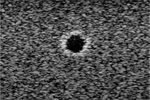

In [ ]:
import shutil

old_dir = "/home/zchen/Code/NeUF_new/data/simu_56/us"
new_dir = "/home/zchen/Code/NeUF_new/data/simu_56/us_0"
os.rename(old_dir, new_dir)

# Get resized US image

In [ ]:
import torch

torch.load("/home/zchen/Code/NeUF_new/logs/simu_56_neuf/checkpoints/best_model.pth")

In [2]:
from PIL import Image
import numpy as np
im = Image.open("D:\\0-Code\\NeUF\\data\\bluephantom\\sync\\export\\us\\us0.jpg").convert('L')
np.array(im).shape

(173, 143)

In [ ]:
from PIL import Image
import numpy as np
im = Image.open("D:\\0-Code\\NeUF\\data\\cerebral_data\\Pre_traitement_echo_v2\\Recalage\\Patient0\\us_recal_original\\us0.jpg").convert('L')
np.array(im).shape

## GT image

In [2]:
import torch
import matplotlib.pyplot as plt

# Process all A1, B1, C1, D1 ground truth files
base_path = r"logs\27-02-2026\HASH_Patient0_0\images"
slice_names = ['A1', 'B1', 'C1', 'D1']

for name in slice_names:
    # Load the .pt file
    gt_tensor = torch.load(f"{base_path}\\{name}_gt.pt")
    
    # Convert to numpy and save as PNG
    output_path = f"{base_path}\\{name}_gt_converted.png"
    plt.imsave(output_path, gt_tensor.cpu().numpy(), cmap='gray')
    
    print(f"Saved {name}: {output_path}")
    print(f"  Tensor shape: {gt_tensor.shape}")

print("\nAll ground truth images converted to PNG!")

Saved A1: logs\27-02-2026\HASH_Patient0_0\images\A1_gt_converted.png
  Tensor shape: torch.Size([290, 212])
Saved B1: logs\27-02-2026\HASH_Patient0_0\images\B1_gt_converted.png
  Tensor shape: torch.Size([290, 212])
Saved C1: logs\27-02-2026\HASH_Patient0_0\images\C1_gt_converted.png
  Tensor shape: torch.Size([290, 212])
Saved D1: logs\27-02-2026\HASH_Patient0_0\images\D1_gt_converted.png
  Tensor shape: torch.Size([290, 212])

All ground truth images converted to PNG!


# Evaluation

## PSNR MSE

In [25]:
import torch
import numpy as np
from pathlib import Path
from nerf_network import NeRF
from dataset_1 import Dataset
from slice_renderer import SliceRenderer

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load checkpoint
checkpoint_path = r"logs\27-02-2026\HASH_Patient0_0\checkpoints\5000.pkl"
ckpt = torch.load(checkpoint_path, map_location=device)

print(f"Loaded checkpoint from: {checkpoint_path}")
print(f"Checkpoint keys: {list(ckpt.keys())}")

# Load dataset
dataset = Dataset.open_from_save(ckpt["baked_dataset_file"])
print(f"Dataset loaded: {dataset.name}")

# Reconstruct NeRF model
nerf = NeRF(ckpt)
nerf.to(device)
print(f"NeRF model loaded with encoding: {nerf.get_encode_name()}")

# Create slice renderer
slice_renderer = SliceRenderer(dataset)

# Calculate PSNR for test set (valid slices)
mse_loss = torch.nn.MSELoss()
psnr_values = []

print("\nCalculating PSNR for valid test set...")
with torch.no_grad():
    for slice_idx in range(4):  # A1, B1, C1, D1
        # Render slice
        rendered = slice_renderer.render_slice_from_dataset_valid(nerf, slice_idx, reshaped=True)
        
        # Get ground truth
        gt = torch.reshape(dataset.get_slice_valid_pixels(slice_idx), 
                          (dataset.px_height, dataset.px_width))
        
        # Calculate MSE
        mse = mse_loss(rendered, gt)
        
        # Calculate PSNR
        psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))
        psnr_values.append(psnr.item())
        
        print(f"  Slice {['A1', 'B1', 'C1', 'D1'][slice_idx]}: PSNR = {psnr.item():.4f} dB, MSE = {mse.item():.6f}")

# Calculate average PSNR
avg_psnr = np.mean(psnr_values)
print(f"\nAverage PSNR: {avg_psnr:.4f} dB")

Loaded checkpoint from: logs\27-02-2026\HASH_Patient0_0\checkpoints\5000.pkl
Checkpoint keys: ['encoding', 'use_directions', 'use_encoding', 'network_fn_state_dict', 'bounding_box', 'n_levels', 'n_features_per_level', 'log2_hashmap_size', 'base_resolution', 'finest_resolution', 'hash_encoder_state', 'seed', 'baked', 'baked_dataset_file', 'optimizer_state_dict', 'start']
Dataset loaded: Patient0
NeRF model loaded with encoding: HASH

Calculating PSNR for valid test set...
  Slice A1: PSNR = -0.5576 dB, MSE = 1.137003
  Slice B1: PSNR = -1.0394 dB, MSE = 1.270400
  Slice C1: PSNR = -1.1777 dB, MSE = 1.311505
  Slice D1: PSNR = -1.9640 dB, MSE = 1.571824

Average PSNR: -1.1847 dB


In [5]:
# Check number of valid slices in dataset
print(f"Total number of valid slices in dataset: {len(dataset.slices_valid)}")
print(f"Dataset info:")
print(f"  Total slices: {len(dataset.slices)}")
print(f"  Valid slices: {len(dataset.slices_valid)}")
if hasattr(dataset, 'slices_test'):
    print(f"  Test slices: {len(dataset.slices_test)}")


Total number of valid slices in dataset: 4
Dataset info:
  Total slices: 241
  Valid slices: 4


In [26]:
# Check tensor value ranges and recalculate PSNR with correct MAX value
print("Checking tensor value ranges...")
print(f"Rendered tensor: min={rendered.min():.6f}, max={rendered.max():.6f}")
print(f"GT tensor: min={gt.min():.6f}, max={gt.max():.6f}")

# Determine MAX value based on range
max_value = max(rendered.max().item(), gt.max().item())
if max_value <= 1.0:
    max_val_for_psnr = 1.0
elif max_value <= 255.0:
    max_val_for_psnr = 255.0
else:
    max_val_for_psnr = max_value

print(f"\nUsing MAX value for PSNR: {max_val_for_psnr}")

# Recalculate PSNR with correct MAX value
print("\nRecalculating PSNR for all valid test set slices with correct MAX value...")
mse_loss = torch.nn.MSELoss()
psnr_corrected = []
mse_values = []

with torch.no_grad():
    for slice_idx in range(len(dataset.slices_valid)):
        # Render slice
        rendered = slice_renderer.render_slice_from_dataset_valid(nerf, slice_idx, reshaped=True)
        
        # Get ground truth
        gt = torch.reshape(dataset.get_slice_valid_pixels(slice_idx), 
                          (dataset.px_height, dataset.px_width))
        
        # Calculate MSE
        mse = mse_loss(rendered, gt)
        mse_values.append(mse.item())
        
        # Calculate PSNR with correct MAX value
        psnr = 20 * torch.log10(torch.tensor(max_val_for_psnr) / torch.sqrt(mse))
        psnr_corrected.append(psnr.item())
        
        print(f"  Slice {slice_idx}: PSNR = {psnr.item():.4f} dB, MSE = {mse.item():.6f}")

# Calculate average PSNR and MSE
avg_psnr_corrected = np.mean(psnr_corrected)
avg_mse = np.mean(mse_values)
print(f"\n========== Summary ==========")
print(f"Average PSNR (all {len(dataset.slices_valid)} valid slices): {avg_psnr_corrected:.4f} dB")
print(f"Average MSE (all {len(dataset.slices_valid)} valid slices): {avg_mse:.6f}")
print(f"============================")


Checking tensor value ranges...
Rendered tensor: min=0.278728, max=132.962677
GT tensor: min=0.000000, max=132.000000

Using MAX value for PSNR: 255.0

Recalculating PSNR for all valid test set slices with correct MAX value...
  Slice 0: PSNR = 47.5732 dB, MSE = 1.137003
  Slice 1: PSNR = 47.0914 dB, MSE = 1.270400
  Slice 2: PSNR = 46.9531 dB, MSE = 1.311505
  Slice 3: PSNR = 46.1668 dB, MSE = 1.571824

========== Summary ==========
Average PSNR (all 4 valid slices): 46.9461 dB
Average MSE (all 4 valid slices): 1.322683


## Render Image

Generating 3 uniformly spaced intermediate images between slice 178 and 179...
Interpolation t values: [0.25 0.5  0.75]


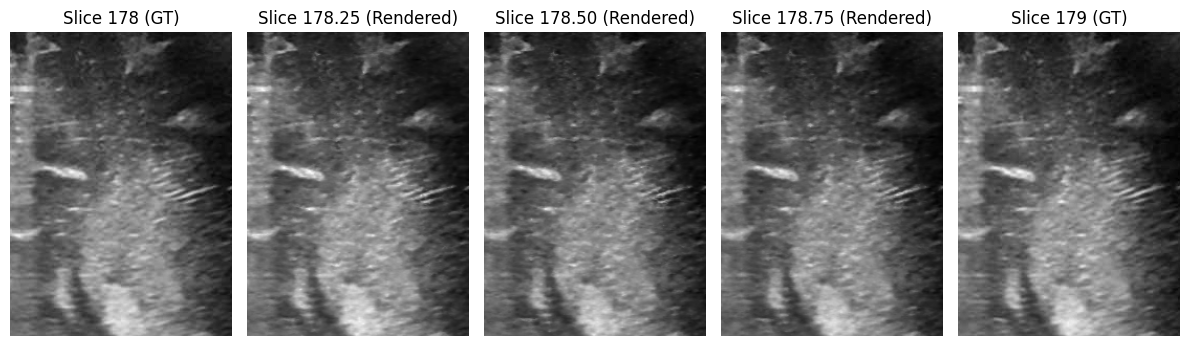


Interpolated images saved to: logs/27-02-2026/HASH_Patient0_0/images/slice_178_179_interpolated_k3.png
  Slice 178.25: range=[12.877985, 115.264313]
  Slice 178.50: range=[14.688365, 121.969612]
  Slice 178.75: range=[15.150087, 120.580597]


In [19]:
# Render k interpolated images uniformly between two slices
import matplotlib.pyplot as plt
import numpy as np

# Input parameters
slice_start_idx = 178  # Starting slice index
slice_end_idx = 179    # Ending slice index
k = 3                 # Number of intermediate images to generate

print(f"Generating {k} uniformly spaced intermediate images between slice {slice_start_idx} and {slice_end_idx}...")

# Get points from start and end slices
points_start = dataset.get_slice_points(slice_start_idx)
points_end = dataset.get_slice_points(slice_end_idx)

# Get viewdirs from start and end slices
viewdirs_start = dataset.get_slice_viewdirs(slice_start_idx)
viewdirs_end = dataset.get_slice_viewdirs(slice_end_idx)

# Generate k uniformly spaced t values between 0 and 1 (excluding endpoints)
t_values = np.linspace(0, 1, k + 2)[1:-1]

print(f"Interpolation t values: {t_values}")

# Render interpolated images
rendered_images = []
height, width = dataset.px_height, dataset.px_width

with torch.no_grad():
    for t in t_values:
        # Interpolate points and viewdirs
        points_interp = (1 - t) * points_start + t * points_end
        viewdirs_interp = (1 - t) * viewdirs_start + t * viewdirs_end
        
        # Normalize points if needed
        if nerf.encoding_type != "HASH" or not nerf.use_encoding:
            point_min = torch.FloatTensor(dataset.point_min).to(device)
            point_max = torch.FloatTensor(dataset.point_max).to(device)
            max_coord = point_max - point_min
            
            points_normalized = torch.add(
                torch.multiply(torch.divide(torch.add(points_interp, -point_min), max_coord), 2), -1)
        else:
            points_normalized = points_interp
        
        # Query the NeRF model
        rendered = nerf.query(points_normalized, viewdirs_interp)
        rendered_reshaped = torch.reshape(rendered, (height, width))
        rendered_images.append(rendered_reshaped)

# Get ground truth for comparison
gt_start = torch.reshape(dataset.get_slice_pixels(slice_start_idx), (height, width))
gt_end = torch.reshape(dataset.get_slice_pixels(slice_end_idx), (height, width))

# Visualize: Start GT + k intermediate rendered + End GT
fig, axes = plt.subplots(1, k + 2, figsize=(4 * (k ), 4))

# Start slice GT
axes[0].imshow(gt_start.cpu().numpy(), cmap='gray')
axes[0].set_title(f'Slice {slice_start_idx} (GT)')
axes[0].axis('off')

# Intermediate rendered images
for i, rendered_img in enumerate(rendered_images):
    t = t_values[i]
    slice_pos = slice_start_idx + t * (slice_end_idx - slice_start_idx)
    axes[i + 1].imshow(rendered_img.cpu().numpy(), cmap='gray')
    axes[i + 1].set_title(f'Slice {slice_pos:.2f} (Rendered)')
    axes[i + 1].axis('off')

# End slice GT
axes[k + 1].imshow(gt_end.cpu().numpy(), cmap='gray')
axes[k + 1].set_title(f'Slice {slice_end_idx} (GT)')
axes[k + 1].axis('off')

plt.tight_layout()
save_path = f'logs/27-02-2026/HASH_Patient0_0/images/slice_{slice_start_idx}_{slice_end_idx}_interpolated_k{k}.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nInterpolated images saved to: {save_path}")
for i, t in enumerate(t_values):
    slice_pos = slice_start_idx + t * (slice_end_idx - slice_start_idx)
    rendered_img = rendered_images[i]
    print(f"  Slice {slice_pos:.2f}: range=[{rendered_img.min():.6f}, {rendered_img.max():.6f}]")


# Crop Image

(np.float64(-0.5), np.float64(943.5), np.float64(707.5), np.float64(-0.5))

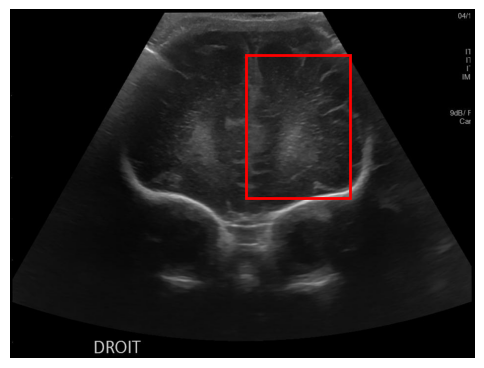

In [21]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

img_path = r"D:\0-Code\NeUF\data\cerebral_data\Pre_traitement_echo_v2\Recalage\Patient0\us_recal_original\us0.jpg"

# Box parameters
x, y, w, h = 478, 93, 212, 290

img = Image.open(img_path).convert("RGB")

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img)
rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
ax.add_patch(rect)
ax.axis('off')



# gCNR

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


def load_raw_file(raw_path):

    mhd_path = raw_path.with_suffix(".mhd")

    metadata = {}
    with mhd_path.open("r") as f:
        for line in f:
            if "=" not in line:
                continue
            key, value = [part.strip() for part in line.split("=", 1)]
            metadata[key] = value

    dim_size_xyz = tuple(map(int, metadata["DimSize"].split()))
    dtype_map = {
        "MET_UCHAR": np.uint8,
        "MET_CHAR": np.int8,
        "MET_USHORT": np.uint16,
        "MET_SHORT": np.int16,
        "MET_UINT": np.uint32,
        "MET_INT": np.int32,
        "MET_FLOAT": np.float32,
        "MET_DOUBLE": np.float64,
    }
    dtype = dtype_map[metadata["ElementType"]]

    volume = np.fromfile(raw_path, dtype=dtype)
    expected_size = int(np.prod(dim_size_xyz))
    if volume.size != expected_size:
        raise ValueError(f"Unexpected raw size: got {volume.size}, expected {expected_size}")

    # MetaImage stores DimSize as x, y, z; reshape to z, y, x for numpy usage.
    volume = volume.reshape(dim_size_xyz[::-1])

    print(f"Volume shape (z, y, x): {volume.shape}")
    print(f"dtype: {volume.dtype}, min: {volume.min()}, max: {volume.max()}")

    mid_z = volume.shape[0] // 2
    plt.figure(figsize=(6, 6))
    plt.imshow(volume[mid_z], cmap="gray")
    plt.title(f"Middle axial slice (z={mid_z})")
    plt.axis("off")
    plt.show()
    
    return volume


def crop_volume(volume):

    # Crop volume to tight bounding box (remove surrounding black/zero regions)
    nz = np.nonzero(volume)
    z_min, z_max = nz[0].min(), nz[0].max()
    y_min, y_max = nz[1].min(), nz[1].max()
    x_min, x_max = nz[2].min(), nz[2].max()

    volume_cropped = volume[z_min:z_max+1, y_min:y_max+1, x_min:x_max+1]

    print(f"Original shape: {volume.shape}")
    print(f"Cropped shape:  {volume_cropped.shape}")
    print(f"BB z: [{z_min}, {z_max}], y: [{y_min}, {y_max}], x: [{x_min}, {x_max}]")

    mid_z = volume_cropped.shape[0] // 2
    plt.figure(figsize=(6, 6))
    plt.imshow(volume_cropped[mid_z], cmap="gray")
    plt.title(f"Cropped middle axial slice (z={mid_z})")
    plt.axis("off")
    plt.show()
    
    return volume_cropped


Volume shape (z, y, x): (728, 798, 943)
dtype: float32, min: 0.0, max: 246.0


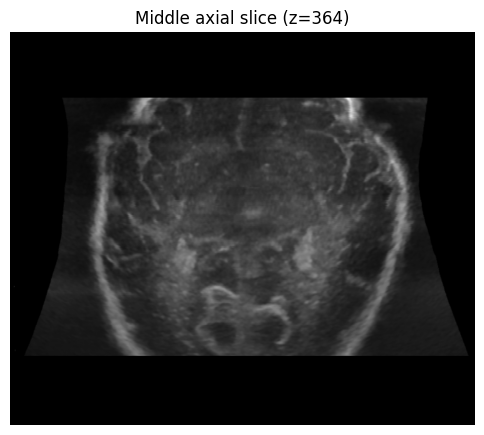

In [6]:
raw_path_knn = Path("/home/zchen/Code/NeUF/exports/recons3d_style_cluster/14-04-2026/ckpt_0/volume.raw")
volume_cropped_knn = load_raw_file(raw_path=raw_path_knn)

Volume shape (z, y, x): (728, 798, 943)
dtype: uint8, min: 0, max: 255


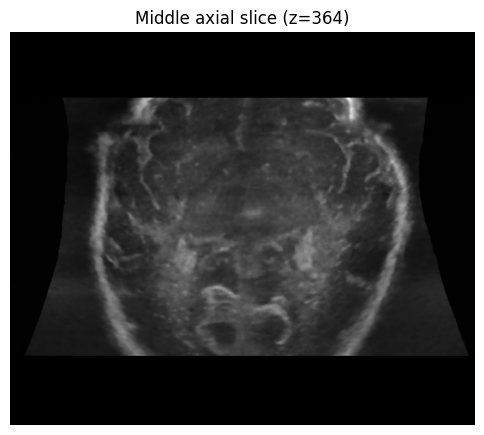

In [5]:
raw_path_nerf = Path("/home/zchen/Code/NeUF/exports/full_grid/31-03-2026/ckpt_2/volume.raw")
volume_cropped_nerf = load_raw_file(raw_path=raw_path_nerf)

In [6]:
out_raw_path = raw_path_knn.parent / (raw_path_knn.stem + "_cropped.raw")
out_mhd_path = out_raw_path.with_suffix(".mhd")

z, y, x = volume_cropped_knn.shape  # array is (z, y, x)

# Write raw — numpy (z,y,x) C-order matches MHD x-fastest layout
volume_cropped_knn.tofile(out_raw_path)

# Write mhd header
with out_mhd_path.open("w") as f:
    f.write("ObjectType = Image\n")
    f.write("NDims = 3\n")
    f.write("BinaryData = True\n")
    f.write("BinaryDataByteOrderMSB = False\n")
    f.write("CompressedData = False\n")
    f.write("TransformMatrix = 1 0 0 0 1 0 0 0 1\n")
    f.write("CenterOfRotation = 0 0 0\n")
    f.write("AnatomicalOrientation = RAI\n")
    f.write("Offset = 0 0 0\n")
    f.write("ElementSpacing = 1 1 1\n")
    f.write(f"DimSize = {x} {y} {z}\n")
    f.write("ElementNumberOfChannels = 1\n")
    f.write("ElementType = MET_UCHAR\n")
    f.write(f"ElementDataFile = {out_raw_path.name}\n")

print(f"Saved to:\n  {out_mhd_path}\n  {out_raw_path}")
print(f"DimSize (x y z): {x} {y} {z}")


Saved to:
  /home/zchen/Code/NeUF/data/cerebral_data/Pre_traitement_echo_v2/Reconstruction_3D/Patient0/data_3D_Patient0_J35_2_mitk_cropped.mhd
  /home/zchen/Code/NeUF/data/cerebral_data/Pre_traitement_echo_v2/Reconstruction_3D/Patient0/data_3D_Patient0_J35_2_mitk_cropped.raw
DimSize (x y z): 940 785 718


## gCNR — Background vs Target

Cube shapes — bg_knn: (50, 50, 50), tg_knn: (50, 50, 50)
Cube shapes — bg_nerf: (50, 50, 50), tg_nerf: (50, 50, 50)

gCNR  KNN : 0.9543
gCNR NeRF : 0.9593


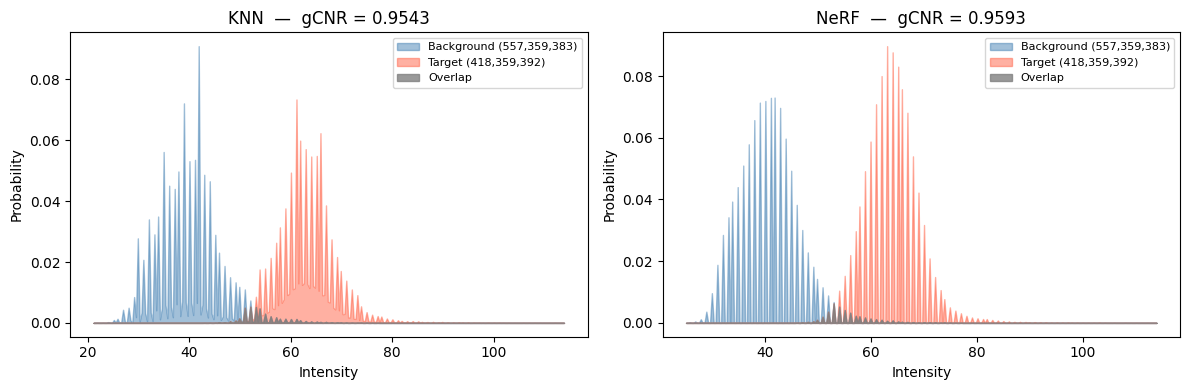

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Coordinates are given as (x, y, z); numpy array is (z, y, x)
# -------------------------------------------------------
BG_CENTER_Z, BG_CENTER_Y, BG_CENTER_X = 557, 359, 383   # background
TG_CENTER_Z, TG_CENTER_Y, TG_CENTER_X = 418, 359, 392   # target
HALF = 25  # half-side: 50 // 2

def extract_cube(volume, cx, cy, cz, half):
    """Extract a cube of side 2*half centered at (cx, cy, cz).
    volume is indexed (z, y, x)."""
    return volume[cz - half : cz + half,
                  cy - half : cy + half,
                  cx - half : cx + half]

def gcnr(bg_voxels, tg_voxels, n_bins=256):
    """Generalised Contrast-to-Noise Ratio.
    gCNR = 1 - sum_i min(p_b(i), p_t(i))
    where p_b, p_t are normalised histograms sharing the same bin edges."""
    v_min = min(bg_voxels.min(), tg_voxels.min())
    v_max = max(bg_voxels.max(), tg_voxels.max())
    bins = np.linspace(v_min, v_max, n_bins + 1)

    hist_bg, _ = np.histogram(bg_voxels, bins=bins, density=False)
    hist_tg, _ = np.histogram(tg_voxels, bins=bins, density=False)

    # Normalise to probability
    p_bg = hist_bg / hist_bg.sum()
    p_tg = hist_tg / hist_tg.sum()

    overlap = np.minimum(p_bg, p_tg).sum()
    return 1.0 - overlap, p_bg, p_tg, bins

# -------------------------------------------------------
# Extract cubes
# -------------------------------------------------------
bg_knn  = extract_cube(volume_cropped_knn,  BG_CENTER_X, BG_CENTER_Y, BG_CENTER_Z, HALF)
tg_knn  = extract_cube(volume_cropped_knn,  TG_CENTER_X, TG_CENTER_Y, TG_CENTER_Z, HALF)
bg_nerf = extract_cube(volume_cropped_nerf, BG_CENTER_X, BG_CENTER_Y, BG_CENTER_Z, HALF)
tg_nerf = extract_cube(volume_cropped_nerf, TG_CENTER_X, TG_CENTER_Y, TG_CENTER_Z, HALF)

print(f"Cube shapes — bg_knn: {bg_knn.shape}, tg_knn: {tg_knn.shape}")
print(f"Cube shapes — bg_nerf: {bg_nerf.shape}, tg_nerf: {tg_nerf.shape}")

# -------------------------------------------------------
# Compute gCNR
# -------------------------------------------------------
gcnr_knn,  p_bg_knn,  p_tg_knn,  bins_knn  = gcnr(bg_knn.flatten(),  tg_knn.flatten())
gcnr_nerf, p_bg_nerf, p_tg_nerf, bins_nerf = gcnr(bg_nerf.flatten(), tg_nerf.flatten())

print(f"\ngCNR  KNN : {gcnr_knn:.4f}")
print(f"gCNR NeRF : {gcnr_nerf:.4f}")

# -------------------------------------------------------
# Plot histograms
# -------------------------------------------------------
bin_centers_knn  = 0.5 * (bins_knn[:-1]  + bins_knn[1:])
bin_centers_nerf = 0.5 * (bins_nerf[:-1] + bins_nerf[1:])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (p_bg, p_tg, bc, label, gval) in zip(axes, [
        (p_bg_knn,  p_tg_knn,  bin_centers_knn,  "KNN",  gcnr_knn),
        (p_bg_nerf, p_tg_nerf, bin_centers_nerf, "NeRF", gcnr_nerf),
]):
    ax.fill_between(bc, p_bg, alpha=0.5, label="Background (557,359,383)", color="steelblue")
    ax.fill_between(bc, p_tg, alpha=0.5, label="Target (418,359,392)",     color="tomato")
    ax.fill_between(bc, np.minimum(p_bg, p_tg), alpha=0.8, label="Overlap", color="gray")
    ax.set_title(f"{label}  —  gCNR = {gval:.4f}")
    ax.set_xlabel("Intensity")
    ax.set_ylabel("Probability")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("gcnr_knn_vs_nerf.png", dpi=150, bbox_inches="tight")
plt.show()


## gCNR — HashGrid Nmax / Levels Sweep

Read every exported `volume.raw` from the Nmax experiment exports and compare gCNR using the same background / target cubes as above.


exp1_A_L16_Nmax512       shape=(728, 798, 943), dtype=uint8, raw=/home/zchen/Code/NeUF/exports/hash_grid_nmax_full_grid/exp1_A_L16_Nmax512/17-04-2026/exp1_A_L16_Nmax512_latest_0/volume.raw
exp1_B_L16_Nmax256       shape=(728, 798, 943), dtype=uint8, raw=/home/zchen/Code/NeUF/exports/hash_grid_nmax_full_grid/exp1_B_L16_Nmax256/17-04-2026/exp1_B_L16_Nmax256_latest_0/volume.raw
exp1_C_L16_Nmax128       shape=(728, 798, 943), dtype=uint8, raw=/home/zchen/Code/NeUF/exports/hash_grid_nmax_full_grid/exp1_C_L16_Nmax128/17-04-2026/exp1_C_L16_Nmax128_latest_0/volume.raw
exp1_D_L16_Nmax64        shape=(728, 798, 943), dtype=uint8, raw=/home/zchen/Code/NeUF/exports/hash_grid_nmax_full_grid/exp1_D_L16_Nmax64/17-04-2026/exp1_D_L16_Nmax64_latest_0/volume.raw
exp1_E_L16_Nmax32        shape=(728, 798, 943), dtype=uint8, raw=/home/zchen/Code/NeUF/exports/hash_grid_nmax_full_grid/exp1_E_L16_Nmax32/17-04-2026/exp1_E_L16_Nmax32_latest_0/volume.raw
exp2_F_L12_Nmax512       shape=(728, 798, 943), dtype=uint8

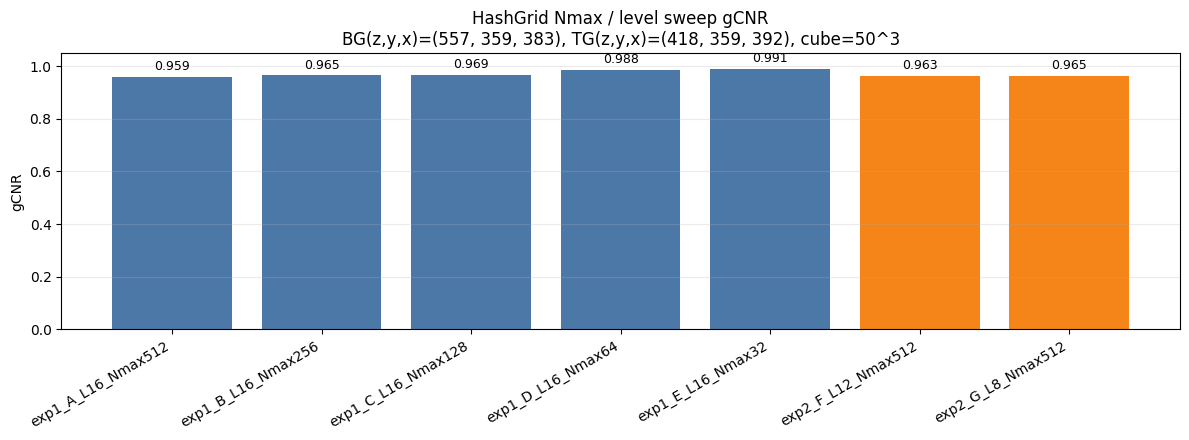

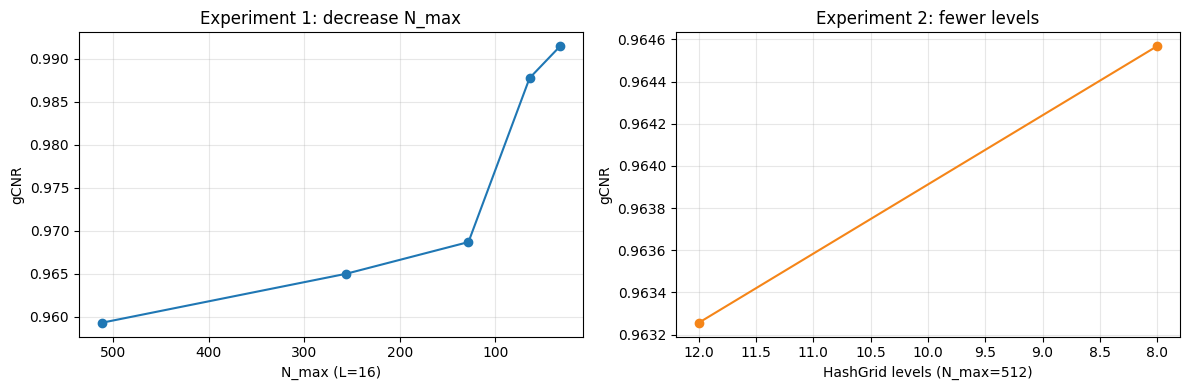

Saved: gcnr_nmax_sweep.csv, gcnr_nmax_sweep.png, gcnr_nmax_sweep_trends.png


In [1]:
from pathlib import Path
import os
import csv
import numpy as np
import matplotlib.pyplot as plt

# Reuse the same ROI centers from the previous gCNR cell when available.
# Coordinates are stored as z/y/x here because numpy volumes are indexed (z, y, x).
if "BG_CENTER_Z" not in globals():
    BG_CENTER_Z, BG_CENTER_Y, BG_CENTER_X = 557, 359, 383
if "TG_CENTER_Z" not in globals():
    TG_CENTER_Z, TG_CENTER_Y, TG_CENTER_X = 418, 359, 392
if "HALF" not in globals():
    HALF = 25

NMAX_EXPORT_ROOT = Path("/home/zchen/Code/NeUF/exports/hash_grid_nmax_full_grid")
EXPERIMENT_ORDER = [
    "exp1_A_L16_Nmax512",
    "exp1_B_L16_Nmax256",
    "exp1_C_L16_Nmax128",
    "exp1_D_L16_Nmax64",
    "exp1_E_L16_Nmax32",
    "exp2_F_L12_Nmax512",
    "exp2_G_L8_Nmax512",
]

USE_MEMMAP = True      # Keeps RAM usage low while still making all volumes accessible.
NONZERO_ONLY = False   # Keep False to match the previous gCNR cell exactly.
N_BINS = 256


def parse_mhd_header(mhd_path: Path):
    metadata = {}
    with mhd_path.open("r", encoding="ascii") as f:
        for line in f:
            if "=" not in line:
                continue
            key, value = [part.strip() for part in line.split("=", 1)]
            metadata[key] = value
    return metadata


def load_mhd_raw(raw_path: Path, use_memmap: bool = True):
    mhd_path = raw_path.with_suffix(".mhd")
    metadata = parse_mhd_header(mhd_path)
    dim_size_xyz = tuple(map(int, metadata["DimSize"].split()))
    shape_zyx = dim_size_xyz[::-1]
    dtype_map = {
        "MET_UCHAR": np.uint8,
        "MET_CHAR": np.int8,
        "MET_USHORT": np.uint16,
        "MET_SHORT": np.int16,
        "MET_UINT": np.uint32,
        "MET_INT": np.int32,
        "MET_FLOAT": np.float32,
        "MET_DOUBLE": np.float64,
    }
    dtype = dtype_map[metadata["ElementType"]]
    expected_size = int(np.prod(shape_zyx))
    actual_size = raw_path.stat().st_size // np.dtype(dtype).itemsize
    if actual_size != expected_size:
        raise ValueError(
            f"Unexpected raw size for {raw_path}: got {actual_size}, expected {expected_size}"
        )
    if use_memmap:
        volume = np.memmap(raw_path, dtype=dtype, mode="r", shape=shape_zyx)
    else:
        volume = np.fromfile(raw_path, dtype=dtype).reshape(shape_zyx)
    return volume, metadata


def latest_raw_for_experiment(experiment: str):
    candidates = sorted(
        (NMAX_EXPORT_ROOT / experiment).glob("*/*/volume.raw"),
        key=lambda p: p.stat().st_mtime,
    )
    if not candidates:
        raise FileNotFoundError(f"No volume.raw found for {experiment} under {NMAX_EXPORT_ROOT}")
    return candidates[-1]


def extract_cube_zyx(volume, center_zyx, half):
    cz, cy, cx = center_zyx
    z0, z1 = cz - half, cz + half
    y0, y1 = cy - half, cy + half
    x0, x1 = cx - half, cx + half
    if z0 < 0 or y0 < 0 or x0 < 0 or z1 > volume.shape[0] or y1 > volume.shape[1] or x1 > volume.shape[2]:
        raise ValueError(
            f"Cube centered at {center_zyx} with half={half} is outside volume shape {volume.shape}"
        )
    return volume[z0:z1, y0:y1, x0:x1]


def gcnr_voxels(bg_voxels, tg_voxels, n_bins=256):
    bg_voxels = np.asarray(bg_voxels, dtype=np.float32).ravel()
    tg_voxels = np.asarray(tg_voxels, dtype=np.float32).ravel()
    if NONZERO_ONLY:
        bg_voxels = bg_voxels[bg_voxels > 0]
        tg_voxels = tg_voxels[tg_voxels > 0]
    if bg_voxels.size == 0 or tg_voxels.size == 0:
        return np.nan, None, None, None

    v_min = float(min(bg_voxels.min(), tg_voxels.min()))
    v_max = float(max(bg_voxels.max(), tg_voxels.max()))
    if v_max <= v_min:
        return 0.0, None, None, None

    bins = np.linspace(v_min, v_max, n_bins + 1)
    hist_bg, _ = np.histogram(bg_voxels, bins=bins, density=False)
    hist_tg, _ = np.histogram(tg_voxels, bins=bins, density=False)
    p_bg = hist_bg / max(hist_bg.sum(), 1)
    p_tg = hist_tg / max(hist_tg.sum(), 1)
    overlap = np.minimum(p_bg, p_tg).sum()
    return float(1.0 - overlap), p_bg, p_tg, bins


# Read every exported raw volume for the sweep.
nmax_raw_paths = {exp: latest_raw_for_experiment(exp) for exp in EXPERIMENT_ORDER}
nmax_volumes = {}
nmax_metadata = {}
for exp, raw_path in nmax_raw_paths.items():
    volume, metadata = load_mhd_raw(raw_path, use_memmap=USE_MEMMAP)
    nmax_volumes[exp] = volume
    nmax_metadata[exp] = metadata
    print(f"{exp:<24} shape={volume.shape}, dtype={volume.dtype}, raw={raw_path}")

rows = []
histograms = {}
bg_center = (BG_CENTER_Z, BG_CENTER_Y, BG_CENTER_X)
tg_center = (TG_CENTER_Z, TG_CENTER_Y, TG_CENTER_X)

for exp, volume in nmax_volumes.items():
    bg_cube = extract_cube_zyx(volume, bg_center, HALF)
    tg_cube = extract_cube_zyx(volume, tg_center, HALF)
    gval, p_bg, p_tg, bins = gcnr_voxels(bg_cube, tg_cube, n_bins=N_BINS)
    bg_vals = np.asarray(bg_cube, dtype=np.float32).ravel()
    tg_vals = np.asarray(tg_cube, dtype=np.float32).ravel()
    if NONZERO_ONLY:
        bg_vals = bg_vals[bg_vals > 0]
        tg_vals = tg_vals[tg_vals > 0]

    rows.append({
        "experiment": exp,
        "gcnr": gval,
        "bg_mean": float(np.mean(bg_vals)),
        "bg_std": float(np.std(bg_vals)),
        "tg_mean": float(np.mean(tg_vals)),
        "tg_std": float(np.std(tg_vals)),
        "bg_n": int(bg_vals.size),
        "tg_n": int(tg_vals.size),
        "raw_path": str(nmax_raw_paths[exp]),
    })
    histograms[exp] = (p_bg, p_tg, bins)

try:
    import pandas as pd
    nmax_gcnr_df = pd.DataFrame(rows)
    display(nmax_gcnr_df[["experiment", "gcnr", "bg_mean", "bg_std", "tg_mean", "tg_std", "bg_n", "tg_n"]])
    nmax_gcnr_df.to_csv("gcnr_nmax_sweep.csv", index=False)
except ImportError:
    nmax_gcnr_df = rows
    print("experiment,gcnr,bg_mean,bg_std,tg_mean,tg_std,bg_n,tg_n")
    for r in rows:
        print(
            f"{r['experiment']},{r['gcnr']:.6f},{r['bg_mean']:.3f},{r['bg_std']:.3f},"
            f"{r['tg_mean']:.3f},{r['tg_std']:.3f},{r['bg_n']},{r['tg_n']}"
        )
    with open("gcnr_nmax_sweep.csv", "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=rows[0].keys())
        writer.writeheader()
        writer.writerows(rows)

labels = [r["experiment"] for r in rows]
values = [r["gcnr"] for r in rows]

plt.figure(figsize=(12, 4.5))
bars = plt.bar(labels, values, color=["#4C78A8"] * 5 + ["#F58518"] * 2)
plt.ylabel("gCNR")
plt.ylim(0, 1.05)
plt.title(
    "HashGrid Nmax / level sweep gCNR\n"
    f"BG(z,y,x)={bg_center}, TG(z,y,x)={tg_center}, cube={2*HALF}^3"
)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.25)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.015, f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("gcnr_nmax_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

# Separate trend plots for the two planned experiments.
exp1_rows = rows[:5]
exp2_rows = rows[5:]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot([512, 256, 128, 64, 32], [r["gcnr"] for r in exp1_rows], marker="o")
axes[0].invert_xaxis()
axes[0].set_xlabel("N_max (L=16)")
axes[0].set_ylabel("gCNR")
axes[0].set_title("Experiment 1: decrease N_max")
axes[0].grid(alpha=0.3)
axes[1].plot([12, 8], [r["gcnr"] for r in exp2_rows], marker="o", color="#F58518")
axes[1].invert_xaxis()
axes[1].set_xlabel("HashGrid levels (N_max=512)")
axes[1].set_ylabel("gCNR")
axes[1].set_title("Experiment 2: fewer levels")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("gcnr_nmax_sweep_trends.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: gcnr_nmax_sweep.csv, gcnr_nmax_sweep.png, gcnr_nmax_sweep_trends.png")


## NIQE / Edge Slope / Resolution Gain / SNR — HashGrid Sweep

Compute no-reference image quality metrics on the exported Nmax full-grid volumes. Edge slope, resolution gain, and SNR use the same background / target ROIs as the gCNR section above; NIQE is computed only when a true NIQE provider is available in the notebook environment.


/home/zchen/.conda/envs/neuf/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using NIQE provider: pyiqa.niqe(cpu)


[W417 16:35:21.460210633 NNPACK.cpp:62] Could not initialize NNPACK! Reason: Unsupported hardware.


Saved quality metrics to: /home/zchen/Code/NeUF/exports/hash_grid_nmax_full_grid/quality_metrics/quality_metrics_nmax_sweep.csv

experiment                 NIQE    slope_top10  res_gain  SNR_bg_dB  SNR_tg_dB  CNR
--------------------------------------------------------------------------------------------
exp1_A_L16_Nmax512           7.725      164.861     1.000     20.825     21.804   2.966
exp1_B_L16_Nmax256           7.394      162.498     0.986     20.862     22.029   3.037
exp1_C_L16_Nmax128           8.554      128.704     0.781     21.169     22.583   3.183
exp1_D_L16_Nmax64            9.292       65.713     0.399     22.112     24.161   3.605
exp1_E_L16_Nmax32           10.418       29.184     0.177     22.636     25.510   3.902
exp2_F_L12_Nmax512           7.407      147.055     0.892     20.773     22.176   3.014
exp2_G_L8_Nmax512            7.559      134.558     0.816     20.850     22.141   3.024
Saved quality plot to: /home/zchen/Code/NeUF/exports/hash_grid_nmax_full_grid/

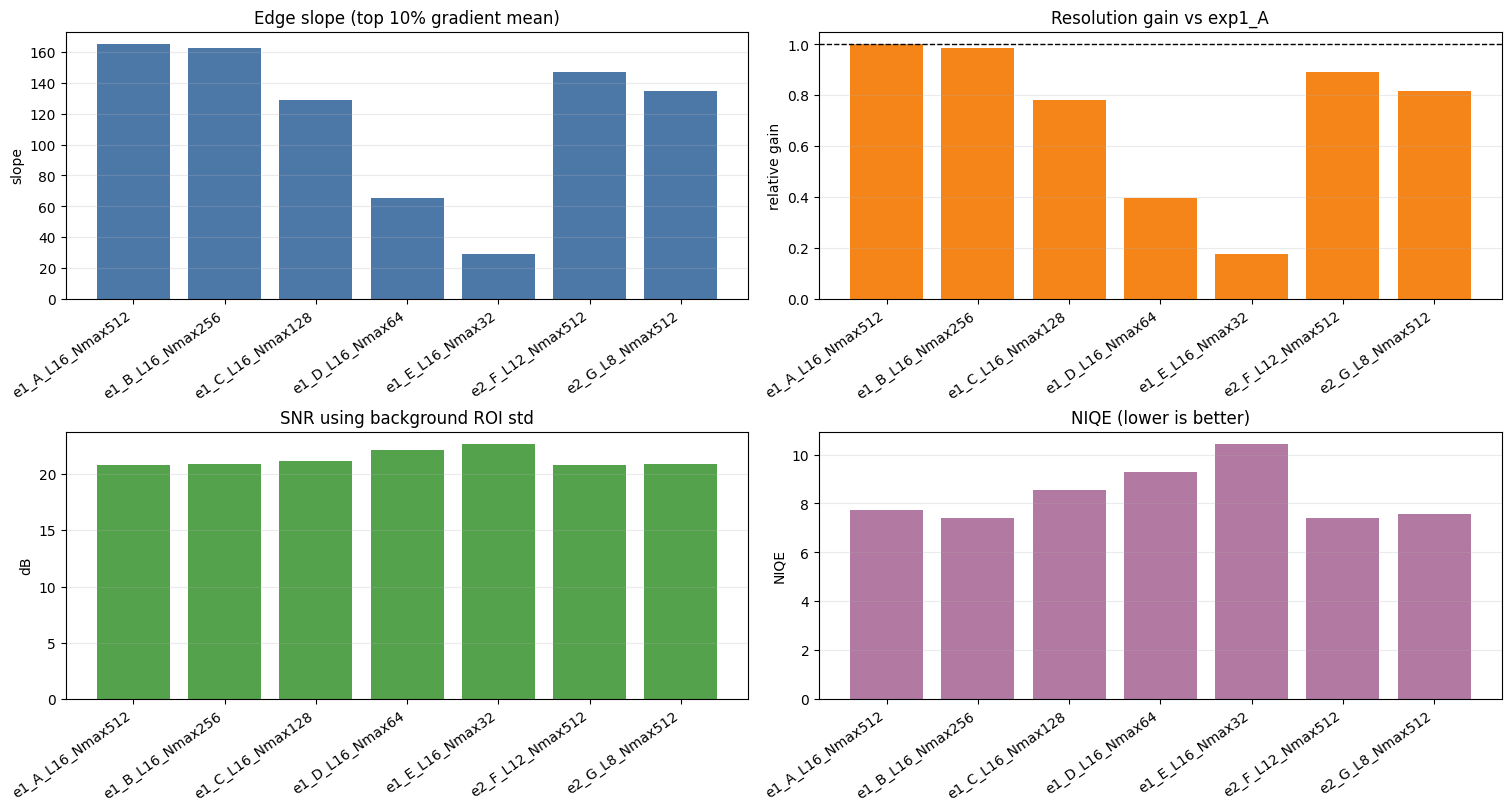

In [3]:
from pathlib import Path
import os
import csv
import math
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# -------------------------------------------------------
# Same Nmax exported volumes and ROI as the gCNR section.
# Coordinates are z/y/x because numpy volumes are indexed (z, y, x).
# -------------------------------------------------------
if "BG_CENTER_Z" not in globals():
    BG_CENTER_Z, BG_CENTER_Y, BG_CENTER_X = 557, 359, 383
if "TG_CENTER_Z" not in globals():
    TG_CENTER_Z, TG_CENTER_Y, TG_CENTER_X = 418, 359, 392
if "HALF" not in globals():
    HALF = 25
if "NMAX_EXPORT_ROOT" not in globals():
    NMAX_EXPORT_ROOT = Path("/home/zchen/Code/NeUF/exports/hash_grid_nmax_full_grid")
if "EXPERIMENT_ORDER" not in globals():
    EXPERIMENT_ORDER = [
        "exp1_A_L16_Nmax512",
        "exp1_B_L16_Nmax256",
        "exp1_C_L16_Nmax128",
        "exp1_D_L16_Nmax64",
        "exp1_E_L16_Nmax32",
        "exp2_F_L12_Nmax512",
        "exp2_G_L8_Nmax512",
    ]

QUALITY_OUTPUT_DIR = NMAX_EXPORT_ROOT / "quality_metrics"
QUALITY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
QUALITY_CSV = QUALITY_OUTPUT_DIR / "quality_metrics_nmax_sweep.csv"
QUALITY_FIG = QUALITY_OUTPUT_DIR / "quality_metrics_nmax_sweep.png"
NIQE_MAX_SLICES = 5      # Uniform slices per volume, plus target/background/mid slices.
NIQE_MAX_IMAGE_SIDE = 512  # Resize long side before NIQE to keep CPU runtime reasonable.

# pyiqa downloads/loads the NIQE pristine model through torch.hub.
# Keep all caches inside the project because /home/zchen/.cache can be read-only
# on cluster/notebook jobs.
PROJECT_CACHE_DIR = Path("/home/zchen/Code/NeUF/.cache")
PROJECT_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ["XDG_CACHE_HOME"] = str(PROJECT_CACHE_DIR)
os.environ["TORCH_HOME"] = str(PROJECT_CACHE_DIR / "torch")
os.environ["HF_HOME"] = str(PROJECT_CACHE_DIR / "huggingface")
Path(os.environ["TORCH_HOME"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["HF_HOME"]).mkdir(parents=True, exist_ok=True)


def parse_mhd_header_local(mhd_path: Path):
    metadata = {}
    with mhd_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            key, value = [part.strip() for part in line.split("=", 1)]
            metadata[key] = value
    return metadata


def load_mhd_raw_local(raw_path: Path, memmap=True):
    mhd_path = raw_path.with_suffix(".mhd")
    metadata = parse_mhd_header_local(mhd_path)
    dim_size = tuple(int(v) for v in metadata["DimSize"].split())
    dtype_map = {
        "MET_UCHAR": np.uint8,
        "MET_CHAR": np.int8,
        "MET_USHORT": np.uint16,
        "MET_SHORT": np.int16,
        "MET_UINT": np.uint32,
        "MET_INT": np.int32,
        "MET_FLOAT": np.float32,
        "MET_DOUBLE": np.float64,
    }
    dtype = dtype_map[metadata.get("ElementType", "MET_UCHAR")]
    shape_zyx = tuple(reversed(dim_size))
    if memmap:
        volume = np.memmap(raw_path, dtype=dtype, mode="r", shape=shape_zyx)
    else:
        volume = np.fromfile(raw_path, dtype=dtype).reshape(shape_zyx)
    return volume, metadata


def latest_raw_for_experiment_local(experiment: str):
    exp_dir = NMAX_EXPORT_ROOT / experiment
    raw_paths = sorted(exp_dir.glob("*/**/volume.raw"), key=lambda p: p.stat().st_mtime, reverse=True)
    if not raw_paths:
        raise FileNotFoundError(f"No volume.raw found for {experiment} under {exp_dir}")
    return raw_paths[0]


def ensure_nmax_volumes_loaded():
    global nmax_volumes, nmax_metadata
    if "nmax_volumes" in globals() and all(exp in nmax_volumes for exp in EXPERIMENT_ORDER):
        return
    nmax_volumes = {}
    nmax_metadata = {}
    for exp in EXPERIMENT_ORDER:
        raw_path = latest_raw_for_experiment_local(exp)
        volume, metadata = load_mhd_raw_local(raw_path, memmap=True)
        nmax_volumes[exp] = volume
        nmax_metadata[exp] = {"raw_path": str(raw_path), **metadata}
        print(f"Loaded {exp}: shape={volume.shape}, raw={raw_path}")


def extract_cube_zyx_local(volume, center_zyx, half):
    z, y, x = center_zyx
    return np.asarray(volume[z - half:z + half, y - half:y + half, x - half:x + half], dtype=np.float32)


def valid_voxels(values, nonzero_only=True):
    values = np.asarray(values, dtype=np.float32).ravel()
    values = values[np.isfinite(values)]
    if nonzero_only:
        nonzero = values[values > 0]
        if nonzero.size:
            values = nonzero
    return values


def edge_slope_metrics(cube):
    cube = np.asarray(cube, dtype=np.float32)
    gz = ndimage.sobel(cube, axis=0, mode="nearest")
    gy = ndimage.sobel(cube, axis=1, mode="nearest")
    gx = ndimage.sobel(cube, axis=2, mode="nearest")
    grad = np.sqrt(gx * gx + gy * gy + gz * gz)
    mask = np.isfinite(grad)
    if np.any(cube > 0):
        mask &= cube > 0
    vals = grad[mask]
    if vals.size == 0:
        vals = grad[np.isfinite(grad)]
    threshold = np.percentile(vals, 90) if vals.size else np.nan
    top_vals = vals[vals >= threshold] if vals.size else vals
    return {
        "edge_slope_mean": float(np.mean(vals)) if vals.size else np.nan,
        "edge_slope_p95": float(np.percentile(vals, 95)) if vals.size else np.nan,
        "edge_slope_top10_mean": float(np.mean(top_vals)) if top_vals.size else np.nan,
    }


def snr_metrics(bg_cube, tg_cube):
    bg = valid_voxels(bg_cube, nonzero_only=True)
    tg = valid_voxels(tg_cube, nonzero_only=True)
    eps = 1e-8
    bg_mean = float(np.mean(bg)) if bg.size else np.nan
    bg_std = float(np.std(bg, ddof=1)) if bg.size > 1 else np.nan
    tg_mean = float(np.mean(tg)) if tg.size else np.nan
    tg_std = float(np.std(tg, ddof=1)) if tg.size > 1 else np.nan
    snr_bg_db = 20.0 * math.log10((abs(tg_mean) + eps) / (bg_std + eps)) if np.isfinite(tg_mean) and np.isfinite(bg_std) else np.nan
    snr_tg_db = 20.0 * math.log10((abs(tg_mean) + eps) / (tg_std + eps)) if np.isfinite(tg_mean) and np.isfinite(tg_std) else np.nan
    cnr = abs(tg_mean - bg_mean) / (math.sqrt(bg_std * bg_std + tg_std * tg_std) + eps) if all(np.isfinite(v) for v in [bg_mean, bg_std, tg_mean, tg_std]) else np.nan
    return {
        "bg_mean": bg_mean,
        "bg_std": bg_std,
        "target_mean": tg_mean,
        "target_std": tg_std,
        "snr_bg_db": float(snr_bg_db),
        "snr_target_db": float(snr_tg_db),
        "cnr": float(cnr),
    }


def normalize_image01(image):
    image = np.asarray(image, dtype=np.float32)
    finite = np.isfinite(image)
    if not finite.any():
        return None
    image = image.copy()
    image[~finite] = 0
    lo, hi = np.percentile(image[finite], [1, 99])
    if hi <= lo:
        lo, hi = float(np.min(image[finite])), float(np.max(image[finite]))
    if hi <= lo:
        return None
    return np.clip((image - lo) / (hi - lo), 0.0, 1.0)


def crop_nonzero_2d(image, margin=8):
    ys, xs = np.nonzero(image > 0)
    if xs.size == 0:
        return image
    y0 = max(int(ys.min()) - margin, 0)
    y1 = min(int(ys.max()) + margin + 1, image.shape[0])
    x0 = max(int(xs.min()) - margin, 0)
    x1 = min(int(xs.max()) + margin + 1, image.shape[1])
    return image[y0:y1, x0:x1]



def resize_for_niqe(image, max_side=NIQE_MAX_IMAGE_SIDE):
    image = np.asarray(image, dtype=np.float32)
    height, width = image.shape
    long_side = max(height, width)
    if long_side <= max_side:
        return image
    scale = max_side / float(long_side)
    new_shape = (max(96, int(round(height * scale))), max(96, int(round(width * scale))))
    try:
        from skimage.transform import resize as skimage_resize
        return skimage_resize(
            image,
            new_shape,
            order=1,
            preserve_range=True,
            anti_aliasing=True,
        ).astype(np.float32)
    except Exception:
        from PIL import Image
        pil = Image.fromarray(image.astype(np.float32), mode="F")
        return np.asarray(pil.resize((new_shape[1], new_shape[0]), resample=Image.Resampling.BILINEAR), dtype=np.float32)

def build_niqe_provider():
    attempts = []
    try:
        from skimage.metrics import niqe as skimage_niqe
        return "skimage.metrics.niqe", lambda image: float(skimage_niqe(normalize_image01(image)))
    except Exception as exc:
        attempts.append(f"skimage.metrics.niqe unavailable: {exc}")
    try:
        import torch
        import pyiqa
        device = "cuda" if torch.cuda.is_available() else "cpu"
        metric = pyiqa.create_metric("niqe", device=device)

        def pyiqa_niqe(image):
            arr = normalize_image01(image)
            if arr is None:
                return np.nan
            tensor = torch.from_numpy(arr)[None, None].to(device)
            with torch.no_grad():
                return float(metric(tensor).detach().cpu().reshape(-1)[0])
        return f"pyiqa.niqe({device})", pyiqa_niqe
    except Exception as exc:
        attempts.append(f"pyiqa unavailable: {exc}")
    try:
        import torch
        import piq
        if not hasattr(piq, "niqe"):
            raise AttributeError("piq.niqe is not available in this PIQ version")

        def piq_niqe(image):
            arr = normalize_image01(image)
            if arr is None:
                return np.nan
            tensor = torch.from_numpy(arr)[None, None]
            with torch.no_grad():
                return float(piq.niqe(tensor, data_range=1.0).detach().cpu().reshape(-1)[0])
        return "piq.niqe", piq_niqe
    except Exception as exc:
        attempts.append(f"piq unavailable: {exc}")
    return None, attempts


def niqe_slice_indices(volume, max_slices=15):
    z_count = volume.shape[0]
    candidates = set(int(v) for v in np.linspace(0, z_count - 1, max_slices))
    candidates.update([BG_CENTER_Z, TG_CENTER_Z, z_count // 2])
    return sorted(z for z in candidates if 0 <= z < z_count)


def niqe_metrics(volume, niqe_fn, max_slices=15):
    if niqe_fn is None:
        return {"niqe_mean": np.nan, "niqe_std": np.nan, "niqe_n_slices": 0}
    scores = []
    for z in niqe_slice_indices(volume, max_slices=max_slices):
        image = np.asarray(volume[z], dtype=np.float32)
        image = crop_nonzero_2d(image)
        image = resize_for_niqe(image)
        if min(image.shape) < 96 or np.count_nonzero(image) < 2048:
            continue
        score = niqe_fn(image)
        if np.isfinite(score):
            scores.append(float(score))
    return {
        "niqe_mean": float(np.mean(scores)) if scores else np.nan,
        "niqe_std": float(np.std(scores, ddof=1)) if len(scores) > 1 else np.nan,
        "niqe_n_slices": len(scores),
    }


def experiment_hash_params(experiment):
    match = re.search(r"L(\d+)_Nmax(\d+)", experiment)
    return {
        "hash_n_levels": int(match.group(1)) if match else np.nan,
        "hash_n_max": int(match.group(2)) if match else np.nan,
    }

ensure_nmax_volumes_loaded()
niqe_provider, niqe_or_attempts = build_niqe_provider()
if niqe_provider is None:
    print("True NIQE provider is not available; NIQE columns will be NaN.")
    for attempt in niqe_or_attempts:
        print("  -", attempt)
    print("Install pyiqa in the notebook kernel to compute true NIQE with this same cell.")
else:
    print(f"Using NIQE provider: {niqe_provider}")

rows = []
for exp in EXPERIMENT_ORDER:
    volume = nmax_volumes[exp]
    bg_cube = extract_cube_zyx_local(volume, (BG_CENTER_Z, BG_CENTER_Y, BG_CENTER_X), HALF)
    tg_cube = extract_cube_zyx_local(volume, (TG_CENTER_Z, TG_CENTER_Y, TG_CENTER_X), HALF)
    row = {"experiment": exp, **experiment_hash_params(exp)}
    row.update(edge_slope_metrics(tg_cube))
    row.update(snr_metrics(bg_cube, tg_cube))
    row.update(niqe_metrics(volume, niqe_or_attempts if niqe_provider else None, max_slices=NIQE_MAX_SLICES))
    row["raw_path"] = nmax_metadata.get(exp, {}).get("raw_path", str(latest_raw_for_experiment_local(exp)))
    rows.append(row)

baseline_exp = "exp1_A_L16_Nmax512"
baseline_slope = next(row["edge_slope_top10_mean"] for row in rows if row["experiment"] == baseline_exp)
for row in rows:
    gain = row["edge_slope_top10_mean"] / baseline_slope if baseline_slope and np.isfinite(baseline_slope) else np.nan
    row["resolution_gain_vs_exp1_A"] = float(gain)
    row["resolution_gain_pct_vs_exp1_A"] = float((gain - 1.0) * 100.0) if np.isfinite(gain) else np.nan

fieldnames = [
    "experiment", "hash_n_levels", "hash_n_max",
    "niqe_mean", "niqe_std", "niqe_n_slices",
    "edge_slope_mean", "edge_slope_p95", "edge_slope_top10_mean",
    "resolution_gain_vs_exp1_A", "resolution_gain_pct_vs_exp1_A",
    "snr_bg_db", "snr_target_db", "cnr",
    "bg_mean", "bg_std", "target_mean", "target_std",
    "raw_path",
]
with QUALITY_CSV.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print(f"Saved quality metrics to: {QUALITY_CSV}")
print("\nexperiment                 NIQE    slope_top10  res_gain  SNR_bg_dB  SNR_tg_dB  CNR")
print("-" * 92)
for row in rows:
    print(
        f"{row['experiment']:<26} "
        f"{row['niqe_mean']:>7.3f} "
        f"{row['edge_slope_top10_mean']:>12.3f} "
        f"{row['resolution_gain_vs_exp1_A']:>9.3f} "
        f"{row['snr_bg_db']:>10.3f} "
        f"{row['snr_target_db']:>10.3f} "
        f"{row['cnr']:>7.3f}"
    )

labels = [row["experiment"].replace("exp", "e") for row in rows]
x = np.arange(len(rows))
fig, axes = plt.subplots(2, 2, figsize=(15, 8), constrained_layout=True)

axes[0, 0].bar(x, [row["edge_slope_top10_mean"] for row in rows], color="#4C78A8")
axes[0, 0].set_title("Edge slope (top 10% gradient mean)")
axes[0, 0].set_ylabel("slope")

axes[0, 1].bar(x, [row["resolution_gain_vs_exp1_A"] for row in rows], color="#F58518")
axes[0, 1].axhline(1.0, color="black", linewidth=1, linestyle="--")
axes[0, 1].set_title("Resolution gain vs exp1_A")
axes[0, 1].set_ylabel("relative gain")

axes[1, 0].bar(x, [row["snr_bg_db"] for row in rows], color="#54A24B")
axes[1, 0].set_title("SNR using background ROI std")
axes[1, 0].set_ylabel("dB")

niqe_values = [row["niqe_mean"] for row in rows]
if any(np.isfinite(niqe_values)):
    axes[1, 1].bar(x, niqe_values, color="#B279A2")
    axes[1, 1].set_title("NIQE (lower is better)")
    axes[1, 1].set_ylabel("NIQE")
else:
    axes[1, 1].axis("off")
    axes[1, 1].text(
        0.5, 0.5,
        "True NIQE provider unavailable\nInstall pyiqa, then rerun this cell",
        ha="center", va="center", fontsize=12,
    )

for ax in axes.ravel()[:3]:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.grid(axis="y", alpha=0.25)
if any(np.isfinite(niqe_values)):
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(labels, rotation=35, ha="right")
    axes[1, 1].grid(axis="y", alpha=0.25)

fig.savefig(QUALITY_FIG, dpi=160, bbox_inches="tight")
print(f"Saved quality plot to: {QUALITY_FIG}")
plt.show()


In [2]:
import pyipa

## SSIM — KNN vs NeRF volume

volume_cropped_knn  shape: (728, 798, 943)
volume_cropped_nerf shape: (728, 798, 943)

Aligned to common shape: (728, 798, 943)  (z, y, x)

Global 3-D SSIM (KNN vs NeRF): 0.9219
Per-slice (z) SSIM — mean: 0.9218  min: 0.4988  max: 0.9980
Per-slice (y) SSIM — mean: 0.9238  min: 0.7696  max: 0.9759


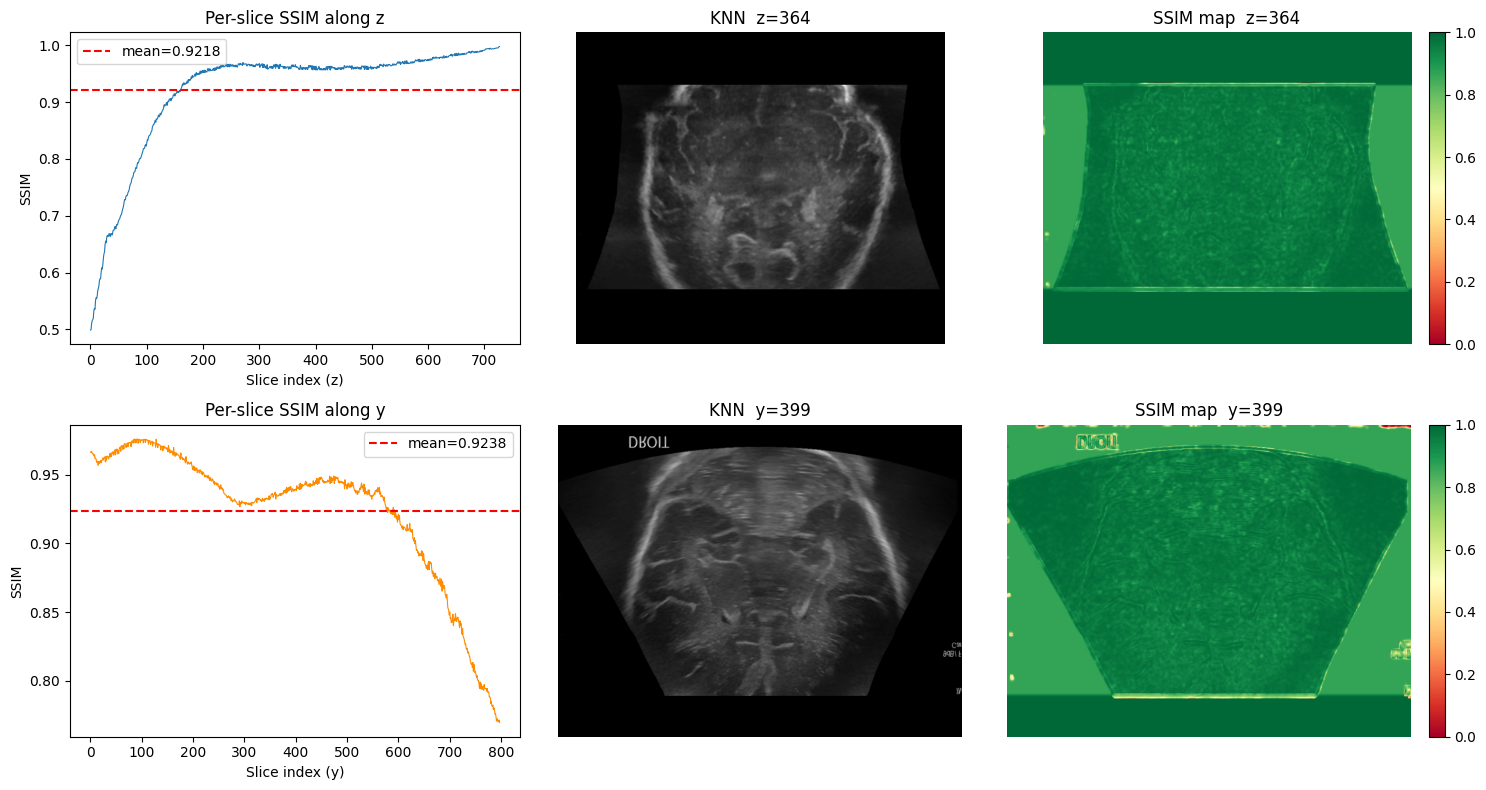

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# -------------------------------------------------------
# Both volumes may have different shapes after independent cropping.
# Align by taking the minimum size along each axis (top-left corner).
# -------------------------------------------------------
knn  = volume_cropped_knn.astype(np.float32)
nerf = volume_cropped_nerf.astype(np.float32)

print(f"volume_cropped_knn  shape: {knn.shape}")
print(f"volume_cropped_nerf shape: {nerf.shape}")

min_z = min(knn.shape[0], nerf.shape[0])
min_y = min(knn.shape[1], nerf.shape[1])
min_x = min(knn.shape[2], nerf.shape[2])

knn_aligned  = knn [:min_z, :min_y, :min_x]
nerf_aligned = nerf[:min_z, :min_y, :min_x]

print(f"\nAligned to common shape: {knn_aligned.shape}  (z, y, x)")

# -------------------------------------------------------
# Global data range across both volumes
# -------------------------------------------------------
data_range = max(knn_aligned.max(), nerf_aligned.max()) - min(knn_aligned.min(), nerf_aligned.min())

# -------------------------------------------------------
# 3-D SSIM (single global value)
# -------------------------------------------------------
ssim_3d, ssim_map_3d = ssim(
    knn_aligned, nerf_aligned,
    data_range=data_range,
    win_size=7,
    full=True,
)
print(f"\nGlobal 3-D SSIM (KNN vs NeRF): {ssim_3d:.4f}")

# -------------------------------------------------------
# Per-slice SSIM along z axis
# -------------------------------------------------------
ssim_per_z = np.array([
    ssim(knn_aligned[z], nerf_aligned[z], data_range=data_range, win_size=7)
    for z in range(min_z)
])
print(f"Per-slice (z) SSIM — mean: {ssim_per_z.mean():.4f}  min: {ssim_per_z.min():.4f}  max: {ssim_per_z.max():.4f}")

# -------------------------------------------------------
# Per-slice SSIM along y axis
# -------------------------------------------------------
ssim_per_y = np.array([
    ssim(knn_aligned[:, y, :], nerf_aligned[:, y, :], data_range=data_range, win_size=7)
    for y in range(min_y)
])
print(f"Per-slice (y) SSIM — mean: {ssim_per_y.mean():.4f}  min: {ssim_per_y.min():.4f}  max: {ssim_per_y.max():.4f}")

# -------------------------------------------------------
# Visualise
# -------------------------------------------------------
mid_z = min_z // 2
mid_y = min_y // 2

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# --- z-axis row ---
axes[0, 0].plot(ssim_per_z, linewidth=0.8)
axes[0, 0].axhline(ssim_per_z.mean(), color="red", linestyle="--", label=f"mean={ssim_per_z.mean():.4f}")
axes[0, 0].set_xlabel("Slice index (z)")
axes[0, 0].set_ylabel("SSIM")
axes[0, 0].set_title("Per-slice SSIM along z")
axes[0, 0].legend()

axes[0, 1].imshow(knn_aligned[mid_z], cmap="gray")
axes[0, 1].set_title(f"KNN  z={mid_z}")
axes[0, 1].axis("off")

im0 = axes[0, 2].imshow(ssim_map_3d[mid_z], cmap="RdYlGn", vmin=0, vmax=1)
axes[0, 2].set_title(f"SSIM map  z={mid_z}")
axes[0, 2].axis("off")
plt.colorbar(im0, ax=axes[0, 2], fraction=0.046, pad=0.04)

# --- y-axis row ---
axes[1, 0].plot(ssim_per_y, linewidth=0.8, color="darkorange")
axes[1, 0].axhline(ssim_per_y.mean(), color="red", linestyle="--", label=f"mean={ssim_per_y.mean():.4f}")
axes[1, 0].set_xlabel("Slice index (y)")
axes[1, 0].set_ylabel("SSIM")
axes[1, 0].set_title("Per-slice SSIM along y")
axes[1, 0].legend()

axes[1, 1].imshow(knn_aligned[:, mid_y, :], cmap="gray")
axes[1, 1].set_title(f"KNN  y={mid_y}")
axes[1, 1].axis("off")

im1 = axes[1, 2].imshow(ssim_map_3d[:, mid_y, :], cmap="RdYlGn", vmin=0, vmax=1)
axes[1, 2].set_title(f"SSIM map  y={mid_y}")
axes[1, 2].axis("off")
plt.colorbar(im1, ax=axes[1, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("ssim_knn_vs_nerf.png", dpi=150, bbox_inches="tight")
plt.show()


In [11]:
import pydicom
from pydicom.dataset import Dataset as DcmDataset
from pydicom.uid import ExplicitVRLittleEndian
import pydicom.uid
import numpy as np
from pathlib import Path
import datetime


def mhd_to_multiframe_dicom(raw_path: Path, output_path: Path):
    """Convert a .raw + .mhd volume to a single multi-frame DICOM file."""
    mhd_path = raw_path.with_suffix(".mhd")
    metadata = {}
    with mhd_path.open("r") as f:
        for line in f:
            if "=" not in line:
                continue
            key, value = [part.strip() for part in line.split("=", 1)]
            metadata[key] = value

    dim_size_xyz = tuple(map(int, metadata["DimSize"].split()))
    spacing_xyz = tuple(map(float, metadata.get("ElementSpacing", "1 1 1").split()))
    offset_xyz = tuple(map(float, metadata.get("Offset", "0 0 0").split()))

    dtype_map = {
        "MET_UCHAR": np.uint8, "MET_CHAR": np.int8,
        "MET_USHORT": np.uint16, "MET_SHORT": np.int16,
        "MET_UINT": np.uint32, "MET_INT": np.int32,
        "MET_FLOAT": np.float32, "MET_DOUBLE": np.float64,
    }
    dtype = dtype_map[metadata["ElementType"]]
    volume = np.fromfile(raw_path, dtype=dtype).reshape(dim_size_xyz[::-1])  # z, y, x

    # Normalize to uint16
    v_min, v_max = float(volume.min()), float(volume.max())
    if v_max > v_min:
        volume_u16 = ((volume.astype(np.float64) - v_min) / (v_max - v_min) * 65535).astype(np.uint16)
    else:
        volume_u16 = np.zeros_like(volume, dtype=np.uint16)

    nz, ny, nx = volume_u16.shape
    now = datetime.datetime.now()

    ds = DcmDataset()
    ds.file_meta = pydicom.Dataset()
    ds.file_meta.MediaStorageSOPClassUID = "1.2.840.10008.5.1.4.1.1.2"  # CT
    ds.file_meta.MediaStorageSOPInstanceUID = pydicom.uid.generate_uid()
    ds.file_meta.TransferSyntaxUID = ExplicitVRLittleEndian

    ds.SOPClassUID = ds.file_meta.MediaStorageSOPClassUID
    ds.SOPInstanceUID = ds.file_meta.MediaStorageSOPInstanceUID
    ds.StudyInstanceUID = pydicom.uid.generate_uid()
    ds.SeriesInstanceUID = pydicom.uid.generate_uid()
    ds.FrameOfReferenceUID = pydicom.uid.generate_uid()

    ds.Modality = "CT"
    ds.Manufacturer = "NeUF"
    ds.StudyDate = now.strftime("%Y%m%d")
    ds.ContentDate = now.strftime("%Y%m%d")
    ds.StudyTime = now.strftime("%H%M%S")
    ds.ContentTime = now.strftime("%H%M%S")

    ds.Rows = ny
    ds.Columns = nx
    ds.NumberOfFrames = nz
    ds.ImagePositionPatient = [float(offset_xyz[0]), float(offset_xyz[1]), float(offset_xyz[2])]
    ds.ImageOrientationPatient = [1, 0, 0, 0, 1, 0]
    ds.PixelSpacing = [float(spacing_xyz[1]), float(spacing_xyz[0])]  # row, col
    ds.SliceThickness = float(spacing_xyz[2])
    ds.SpacingBetweenSlices = float(spacing_xyz[2])

    ds.SamplesPerPixel = 1
    ds.PhotometricInterpretation = "MONOCHROME2"
    ds.BitsAllocated = 16
    ds.BitsStored = 16
    ds.HighBit = 15
    ds.PixelRepresentation = 0
    ds.RescaleIntercept = str(v_min)
    ds.RescaleSlope = str((v_max - v_min) / 65535 if v_max > v_min else 1.0)

    ds.PixelData = volume_u16.tobytes()
    ds.is_little_endian = True
    ds.is_implicit_VR = False

    output_path.parent.mkdir(parents=True, exist_ok=True)
    pydicom.dcmwrite(str(output_path), ds)
    print(f"Saved multi-frame DICOM ({nz} frames, {ny}x{nx}) to {output_path}")


# --- Export KNN ---
mhd_to_multiframe_dicom(raw_path_knn, raw_path_knn.parent / "volume.dcm")

# --- Export NeRF ---
mhd_to_multiframe_dicom(raw_path_nerf, raw_path_nerf.parent / "volume.dcm")

Saved multi-frame DICOM (728 frames, 798x943) to /home/zchen/Code/NeUF/exports/recons3d_style_cluster/14-04-2026/ckpt_0/volume.dcm
Saved multi-frame DICOM (728 frames, 798x943) to /home/zchen/Code/NeUF/exports/full_grid/31-03-2026/ckpt_2/volume.dcm


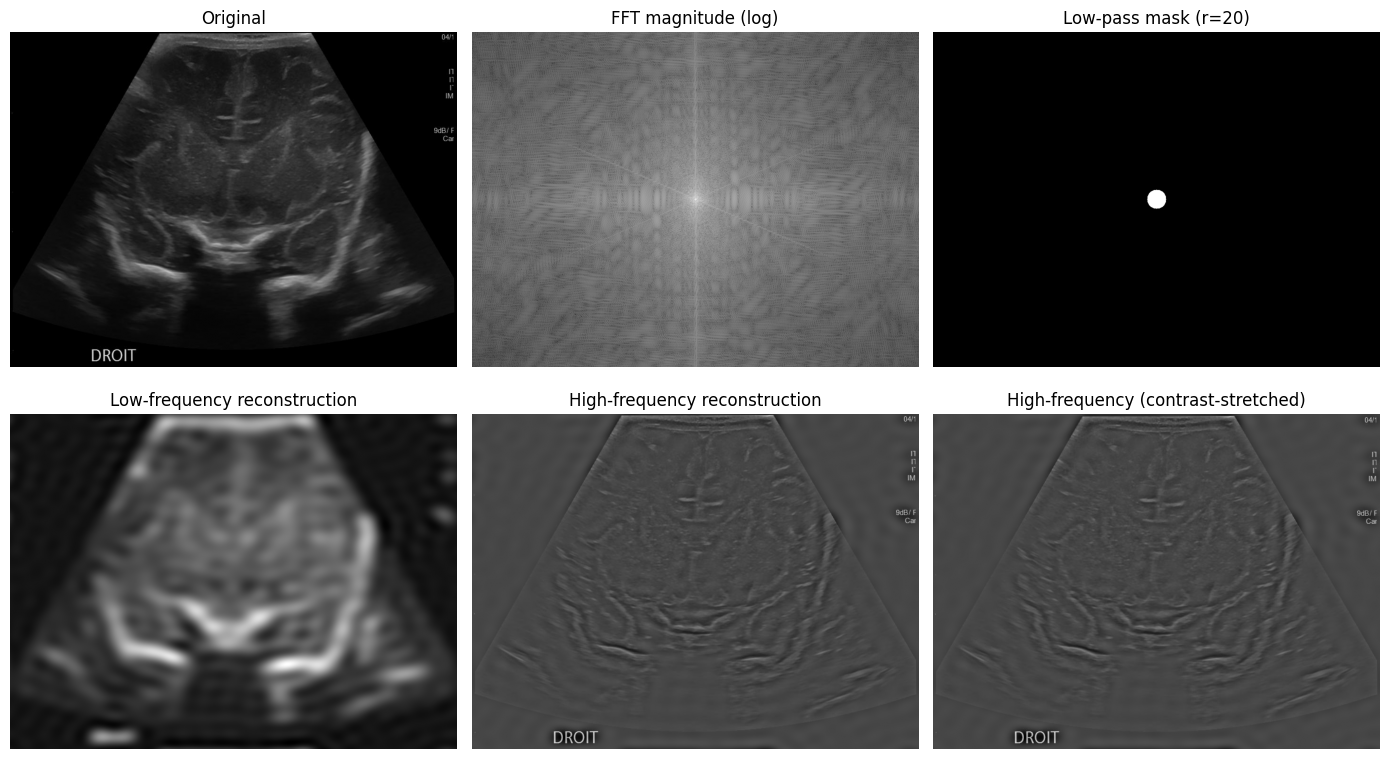

Image shape: (708, 944), dtype after load: float32
Low  recon range: [-12.841, 145.853]
High recon range: [-83.548, 217.446]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img_path = "/home/zchen/Code/NeUF/data/cerebral_data/Pre_traitement_echo_v2/Recalage/Patient0/us_recal_original/us39.jpg"
img = np.array(Image.open(img_path).convert("L"), dtype=np.float32)

# 2D FFT and shift zero-frequency to centre
F = np.fft.fft2(img)
Fshift = np.fft.fftshift(F)
magnitude = np.log1p(np.abs(Fshift))

# Build a circular low-pass / high-pass mask
h, w = img.shape
cy, cx = h // 2, w // 2
radius = 20
# cutoff radius in pixels — smaller = lower frequencies kept


yy, xx = np.ogrid[:h, :w]
dist2 = (yy - cy) ** 2 + (xx - cx) ** 2
low_mask = dist2 <= radius ** 2
high_mask = ~low_mask

# Apply masks in frequency domain
F_low = Fshift * low_mask
F_high = Fshift * high_mask

# Inverse FFT to recover spatial-domain reconstructions
img_low = np.real(np.fft.ifft2(np.fft.ifftshift(F_low)))
img_high = np.real(np.fft.ifft2(np.fft.ifftshift(F_high)))

# Visualise
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].imshow(img, cmap="gray")
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(magnitude, cmap="gray")
axes[0, 1].set_title("FFT magnitude (log)")
axes[0, 1].axis("off")

axes[0, 2].imshow(low_mask, cmap="gray")
axes[0, 2].set_title(f"Low-pass mask (r={radius})")
axes[0, 2].axis("off")

axes[1, 0].imshow(img_low, cmap="gray")
axes[1, 0].set_title("Low-frequency reconstruction")
axes[1, 0].axis("off")

axes[1, 1].imshow(img_high, cmap="gray")
axes[1, 1].set_title("High-frequency reconstruction")
axes[1, 1].axis("off")

# Display high-freq with stretched contrast for visibility
hi_disp = img_high - img_high.min()
hi_disp = hi_disp / (hi_disp.max() + 1e-8)
axes[1, 2].imshow(hi_disp, cmap="gray")
axes[1, 2].set_title("High-frequency (contrast-stretched)")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

print(f"Image shape: {img.shape}, dtype after load: float32")
print(f"Low  recon range: [{img_low.min():.3f}, {img_low.max():.3f}]")
print(f"High recon range: [{img_high.min():.3f}, {img_high.max():.3f}]")

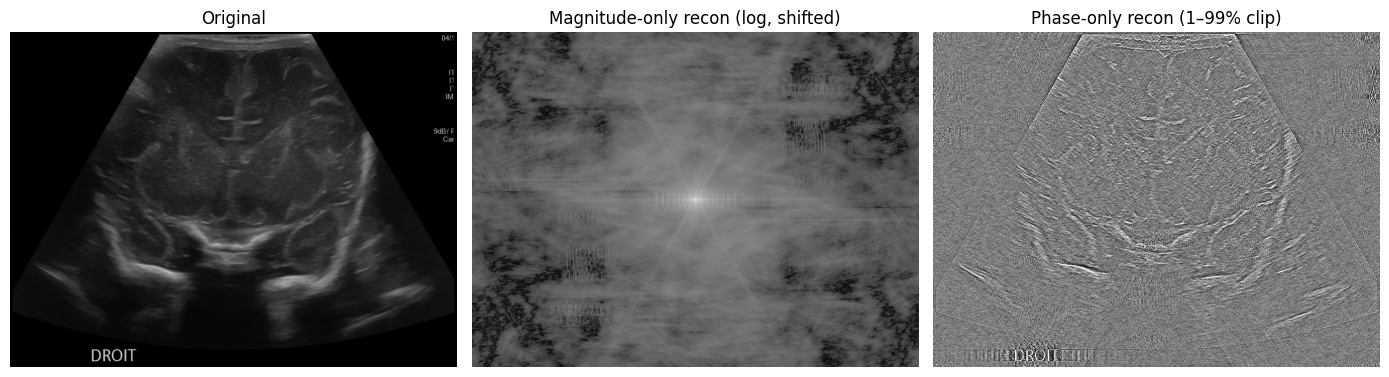

Phase-only recon — full range: [-0.0453, 0.0709]
Phase-only recon — 1–99% range: [-0.0019, 0.0020]
  → outlier ratio: 30.3x


In [5]:
# Magnitude-only vs Phase-only reconstruction
# Reuses `img` and `F` (un-shifted FFT) from the previous cell.

magnitude_spec = np.abs(F)
phase_spec = np.angle(F)

# Magnitude-only: keep |F|, drop phase (set phase = 0)
F_mag_only = magnitude_spec.astype(np.complex64)
img_mag_only = np.real(np.fft.ifft2(F_mag_only))

# Phase-only: keep phase, set |F| = 1
F_phase_only = np.exp(1j * phase_spec)
img_phase_only = np.real(np.fft.ifft2(F_phase_only))

# Percentile-clip + stretch: phase-only has a few delta-like spikes at edges
# that dominate the min/max range; clip them so structure becomes visible.
def percentile_stretch(x, lo=1, hi=99):
    a, b = np.percentile(x, [lo, hi])
    x = np.clip(x, a, b)
    return (x - a) / (b - a + 1e-8)

# fftshift the magnitude-only result so the bright DC blob sits in the centre
img_mag_disp = np.fft.fftshift(img_mag_only)
img_mag_disp = np.log1p(np.abs(img_mag_disp))  # log scale — DC dominates otherwise

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_mag_disp, cmap="gray")
axes[1].set_title("Magnitude-only recon (log, shifted)")
axes[1].axis("off")

axes[2].imshow(percentile_stretch(img_phase_only, 1, 99), cmap="gray")
axes[2].set_title("Phase-only recon (1–99% clip)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Diagnostic: show how extreme the spikes are
p_min, p1, p99, p_max = np.percentile(img_phase_only, [0, 1, 99, 100])
print(f"Phase-only recon — full range: [{p_min:.4f}, {p_max:.4f}]")
print(f"Phase-only recon — 1–99% range: [{p1:.4f}, {p99:.4f}]")
print(f"  → outlier ratio: {(p_max - p_min) / (p99 - p1):.1f}x")

Found 242 frames

Source              mean   median      std
Raw               0.9910   0.9917   0.0034
Speckle σ=4       0.9544   0.9577   0.0191
Speckle σ=8       0.9658   0.9683   0.0131
Speckle σ=16      0.9762   0.9777   0.0087


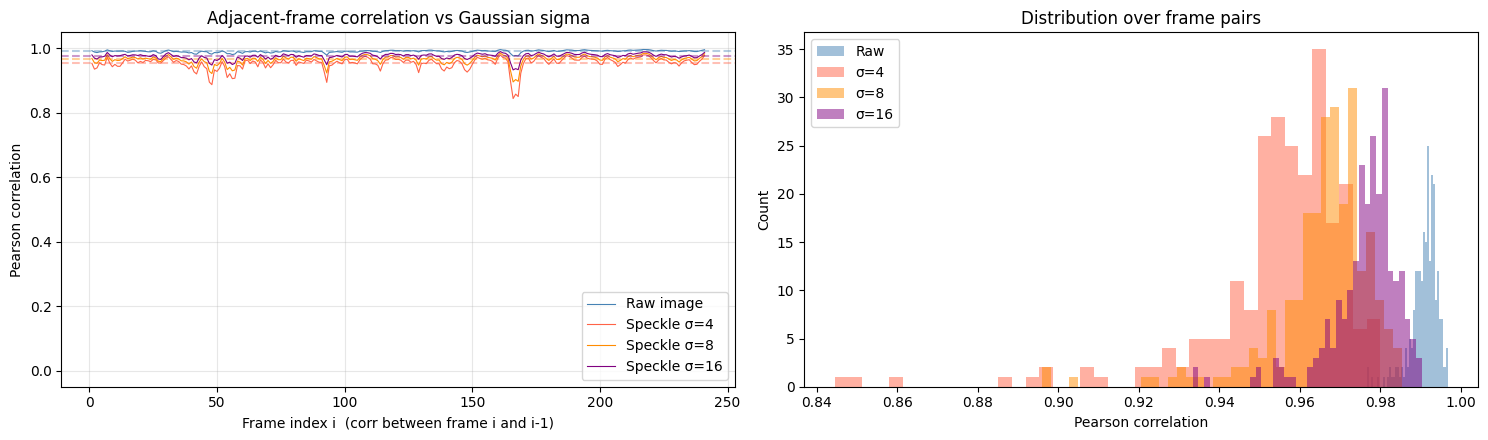

In [8]:
# Speckle correlation between adjacent ultrasound frames
# Compare multiple Gaussian sigmas — larger sigma means a smoother envelope
# is subtracted, so MORE structure is left in the "speckle" residual.

import os
import re
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter

img_dir = "/home/zchen/Code/NeUF/data/cerebral_data/Pre_traitement_echo_v2/Recalage/Patient0/us_recal_original"

files = [f for f in os.listdir(img_dir) if f.lower().endswith(".jpg")]
files.sort(key=lambda f: int(re.search(r"\d+", f).group()))
print(f"Found {len(files)} frames")

SIGMAS = [4, 8, 16]

def masked_pearson(a, b, mask):
    av, bv = a[mask], b[mask]
    av = av - av.mean()
    bv = bv - bv.mean()
    denom = np.sqrt((av * av).sum() * (bv * bv).sum()) + 1e-12
    return float((av * bv).sum() / denom)

# Pre-load all frames once
arrays = [np.asarray(Image.open(os.path.join(img_dir, f)).convert("L"), dtype=np.float32)
          for f in files]

# Raw correlation
corr_raw = []
for i in range(1, len(arrays)):
    a, b = arrays[i-1], arrays[i]
    mask = (a > 0) & (b > 0)
    corr_raw.append(masked_pearson(a, b, mask) if mask.sum() >= 100 else np.nan)
corr_raw = np.array(corr_raw)

# Speckle correlation per sigma
corr_by_sigma = {}
for sigma in SIGMAS:
    speckles = [arr - gaussian_filter(arr, sigma=sigma) for arr in arrays]
    c = []
    for i in range(1, len(arrays)):
        mask = (arrays[i-1] > 0) & (arrays[i] > 0)
        if mask.sum() < 100:
            c.append(np.nan)
        else:
            c.append(masked_pearson(speckles[i-1], speckles[i], mask))
    corr_by_sigma[sigma] = np.array(c)

# Summary table
print(f"\n{'Source':<15} {'mean':>8} {'median':>8} {'std':>8}")
print(f"{'Raw':<15} {np.nanmean(corr_raw):>8.4f} {np.nanmedian(corr_raw):>8.4f} {np.nanstd(corr_raw):>8.4f}")
for sigma in SIGMAS:
    c = corr_by_sigma[sigma]
    print(f"{'Speckle σ='+str(sigma):<15} {np.nanmean(c):>8.4f} {np.nanmedian(c):>8.4f} {np.nanstd(c):>8.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
x = np.arange(1, len(files))
colors = {4: "tomato", 8: "darkorange", 16: "purple"}

axes[0].plot(x, corr_raw, label="Raw image", color="steelblue", lw=0.8)
axes[0].axhline(np.nanmean(corr_raw), color="steelblue", ls="--", alpha=0.4)
for sigma in SIGMAS:
    c = corr_by_sigma[sigma]
    axes[0].plot(x, c, label=f"Speckle σ={sigma}", color=colors[sigma], lw=0.8)
    axes[0].axhline(np.nanmean(c), color=colors[sigma], ls="--", alpha=0.4)
axes[0].set_xlabel("Frame index i  (corr between frame i and i-1)")
axes[0].set_ylabel("Pearson correlation")
axes[0].set_title("Adjacent-frame correlation vs Gaussian sigma")
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(alpha=0.3)
axes[0].legend(loc="lower right")

axes[1].hist(corr_raw[~np.isnan(corr_raw)], bins=40, color="steelblue", alpha=0.5, label="Raw")
for sigma in SIGMAS:
    c = corr_by_sigma[sigma]
    axes[1].hist(c[~np.isnan(c)], bins=40, color=colors[sigma], alpha=0.5, label=f"σ={sigma}")
axes[1].set_xlabel("Pearson correlation")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution over frame pairs")
axes[1].legend()

plt.tight_layout()
plt.show()

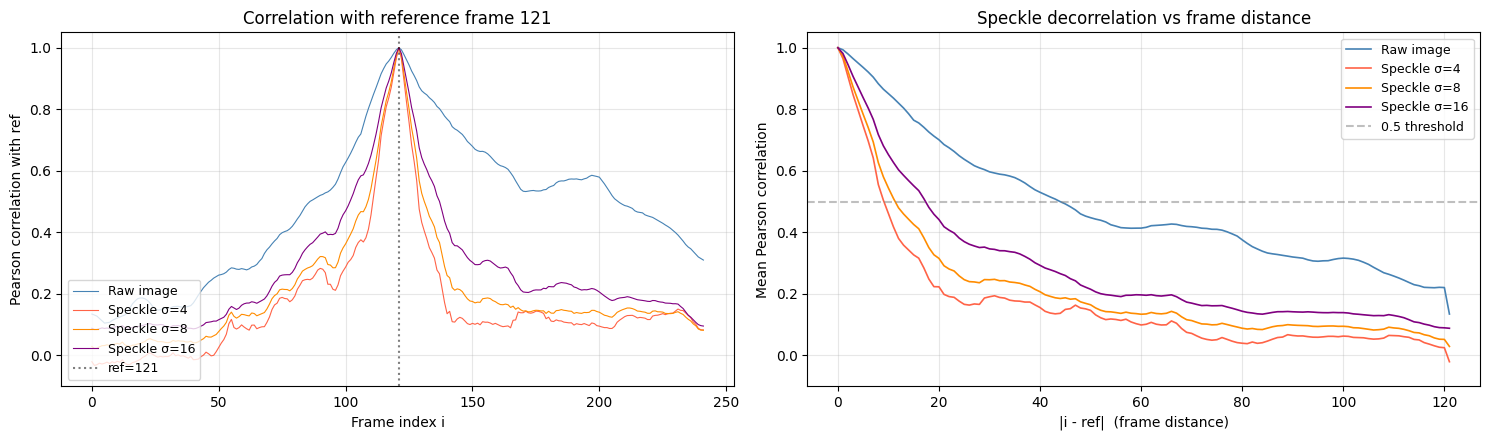

Reference frame: 121 / 241
  σ=4: speckle corr < 0.8 at distance = 4 frames
  σ=8: speckle corr < 0.8 at distance = 5 frames
  σ=16: speckle corr < 0.8 at distance = 7 frames


In [10]:
# Speckle decorrelation vs frame distance from a fixed reference frame
# Pick one ref frame; compute speckle correlation between ref and every
# other frame. This shows how fast speckle decorrelates as we move away.
# Reuses `arrays` and `files` from the previous cell.

REF_IDX = len(arrays) // 2     # default: middle of the sequence
SIGMAS_REF = [4, 8, 16]

ref_arr = arrays[REF_IDX]
ref_speckles = {sigma: ref_arr - gaussian_filter(ref_arr, sigma=sigma) for sigma in SIGMAS_REF}

# Raw correlation against ref
ref_raw = []
for i in range(len(arrays)):
    a = arrays[i]
    mask = (ref_arr > 0) & (a > 0)
    ref_raw.append(masked_pearson(ref_arr, a, mask) if mask.sum() >= 100 else np.nan)
ref_raw = np.array(ref_raw)

# Speckle correlation against ref, per sigma
ref_speckle_corr = {}
for sigma in SIGMAS_REF:
    rs = ref_speckles[sigma]
    c = []
    for i in range(len(arrays)):
        a = arrays[i]
        mask = (ref_arr > 0) & (a > 0)
        if mask.sum() < 100:
            c.append(np.nan)
            continue
        cur_speckle = a - gaussian_filter(a, sigma=sigma)
        c.append(masked_pearson(rs, cur_speckle, mask))
    ref_speckle_corr[sigma] = np.array(c)

# Plot: left = correlation vs absolute frame index, right = vs distance from ref
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
x = np.arange(len(arrays))
colors = {4: "tomato", 8: "darkorange", 16: "purple"}

axes[0].plot(x, ref_raw, label="Raw image", color="steelblue", lw=0.8)
for sigma in SIGMAS_REF:
    axes[0].plot(x, ref_speckle_corr[sigma], label=f"Speckle σ={sigma}", color=colors[sigma], lw=0.8)
axes[0].axvline(REF_IDX, color="black", ls=":", alpha=0.5, label=f"ref={REF_IDX}")
axes[0].set_xlabel("Frame index i")
axes[0].set_ylabel("Pearson correlation with ref")
axes[0].set_title(f"Correlation with reference frame {REF_IDX}")
axes[0].set_ylim(-0.1, 1.05)
axes[0].grid(alpha=0.3)
axes[0].legend(loc="lower left", fontsize=9)

# Decorrelation curve as function of distance — average over symmetric pairs
abs_dist = np.abs(np.arange(len(arrays)) - REF_IDX)
max_d = abs_dist.max()

def avg_by_distance(corr):
    out = np.full(max_d + 1, np.nan)
    for d in range(max_d + 1):
        vals = corr[abs_dist == d]
        vals = vals[~np.isnan(vals)]
        if len(vals) > 0:
            out[d] = vals.mean()
    return out

axes[1].plot(np.arange(max_d + 1), avg_by_distance(ref_raw),
             label="Raw image", color="steelblue", lw=1.2)
for sigma in SIGMAS_REF:
    axes[1].plot(np.arange(max_d + 1), avg_by_distance(ref_speckle_corr[sigma]),
                 label=f"Speckle σ={sigma}", color=colors[sigma], lw=1.2)
axes[1].axhline(0.5, color="gray", ls="--", alpha=0.5, label="0.5 threshold")
axes[1].set_xlabel("|i - ref|  (frame distance)")
axes[1].set_ylabel("Mean Pearson correlation")
axes[1].set_title("Speckle decorrelation vs frame distance")
axes[1].set_ylim(-0.1, 1.05)
axes[1].grid(alpha=0.3)
axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

# Print where speckle correlation crosses 0.5 (rough decorrelation length)
print(f"Reference frame: {REF_IDX} / {len(arrays)-1}")
for sigma in SIGMAS_REF:
    avg = avg_by_distance(ref_speckle_corr[sigma])
    below = np.where(avg < 0.8)[0]
    d50 = below[0] if len(below) > 0 else None
    print(f"  σ={sigma}: speckle corr < 0.8 at distance = "
          f"{d50 if d50 is not None else '> ' + str(max_d)} frames")